In [46]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import tifffile
import torch

from matplotlib.collections import PolyCollection
from shapely.ops import unary_union
from shapely.strtree import STRtree
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

%matplotlib inline

# What is our generic strategy?

1. Take all fo the norkin_organoid images
2. Begin to do preprocessing on them
3. Visualize them and see what a reasonable way to do organoid segmentation is

In [34]:
organoid_boundary_pth = "/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/data/xenium/raw/CRC_PDO/hImmune_v1_mm/1CFW/output-XETG00059__0021738__1CFW__20250319__172035/cell_boundaries.parquet"
pq = pd.read_parquet(organoid_boundary_pth)

In [50]:
def visualize_cell_segmentation(parquet_path, limit=None):
    """
    Visualize cell segmentation masks from a Parquet file.
    
    Parameters:
    - parquet_path: Path to the Parquet file
    - limit_to_first_100: If True, only shows first 100 cell IDs (default: True)
    """
    # Read the Parquet file
    df = pd.read_parquet(parquet_path)
    
    # Get unique cell IDs
    unique_cell_ids = df['cell_id'].unique()
    
    # Optionally limit to first 100 cell IDs
    if limit is not None and len(unique_cell_ids) > limit:
        print(f"Limiting display to first 100 of {len(unique_cell_ids)} total cell IDs")
        selected_cell_ids = unique_cell_ids[:limit]
        df = df[df['cell_id'].isin(selected_cell_ids)]
    
    # Group vertices by cell_id
    polygons = []
    colors = []
    
    # Create a colormap for visualization
    cmap = plt.cm.get_cmap('tab20', len(df['cell_id'].unique()))
    
    for i, (cell_id, group) in enumerate(df.groupby('cell_id')):
        # Get vertices in order
        vertices = list(zip(group['vertex_x'], group['vertex_y']))
        polygons.append(vertices)
        colors.append(cmap(i))
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Add polygons to plot
    poly_collection = PolyCollection(
        polygons,
        facecolors=colors,
        edgecolors='black',
        linewidths=0.5,
        alpha=0.7
    )
    ax.add_collection(poly_collection)
    
    # Auto-scale the plot
    ax.autoscale()
    
    # Set labels and title
    ax.set_title('Cell Segmentation Visualization')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    
    # Add colorbar legend
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=len(df['cell_id'].unique())-1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Cell ID')
    
    plt.show()


In [3]:
visualize_cell_segmentation(organoid_boundary_pth, limit=None)

NameError: name 'organoid_boundary_pth' is not defined

In [51]:
def create_organoid_regions(parquet_path, buffer_distance=5, min_cell_count=20, plot_results=True):
    """
    Create organoid regions by merging overlapping or nearby cell polygons.
    
    Parameters:
    - parquet_path: Path to the Parquet file
    - buffer_distance: Distance to expand cells for merging (in coordinate units)
    - min_cell_count: Minimum number of cells required to form an organoid (default: 20)
    - plot_results: Whether to plot the results (default: True)
    
    Returns:
    - organoids: List of Shapely Polygon/MultiPolygon objects
    - cell_counts: List of cell counts for each organoid
    - bounding_boxes: List of bounding boxes as (min_x, min_y, max_x, max_y) tuples
    """
    # Read the Parquet file
    df = pd.read_parquet(parquet_path)
    
    # Create dictionary to store cell polygons and their buffered versions
    cell_polygons = {}
    buffered_polygons = []
    
    # Convert each cell to a Shapely polygon and create buffered versions
    for cell_id, group in df.groupby('cell_id'):
        vertices = list(zip(group['vertex_x'], group['vertex_y']))
        poly = Polygon(vertices)
        cell_polygons[cell_id] = poly
        buffered_polygons.append(poly.buffer(buffer_distance))
    
    # Build spatial index for faster queries
    tree = STRtree(buffered_polygons)
    
    # Find connected components (organoids) using union-find approach
    parent = {i: i for i in range(len(buffered_polygons))}
    
    def find(u):
        while parent[u] != u:
            parent[u] = parent[parent[u]]
            u = parent[u]
        return u
    
    # Find all intersecting polygons and merge them
    for i, poly in enumerate(buffered_polygons):
        for j in tree.query(poly):
            if i != j and poly.intersects(buffered_polygons[j]):
                root_i = find(i)
                root_j = find(j)
                if root_i != root_j:
                    parent[root_j] = root_i
    
    # Group polygons by their root parent
    groups = {}
    for i in range(len(buffered_polygons)):
        root = find(i)
        if root not in groups:
            groups[root] = []
        groups[root].append(i)
    
    # Filter groups by cell count and create merged organoids
    organoids = []
    cell_counts = []
    bounding_boxes = []
    valid_original_cells = []  # For visualization
    
    for group_indices in groups.values():
        if len(group_indices) >= min_cell_count:
            # Get the original polygons (not buffered)
            original_polys = [list(cell_polygons.values())[i] for i in group_indices]
            valid_original_cells.extend(original_polys)
            
            # Merge the buffered versions
            to_merge = [buffered_polygons[i] for i in group_indices]
            merged = unary_union(to_merge)
            
            # Sometimes buffer creates small artifacts - we can simplify
            merged = merged.simplify(buffer_distance/2)
            organoids.append(merged)
            cell_counts.append(len(group_indices))
            
            # Get bounding box (min_x, min_y, max_x, max_y)
            bounding_boxes.append(merged.bounds)
    
    if plot_results:
        # Create figure
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        
        # Plot original cells (only those that contributed to organoids)
        original_patches = []
        for poly in valid_original_cells:
            original_patches.append(plt.Polygon(np.array(poly.exterior.coords), closed=True))
        
        pc1 = PatchCollection(original_patches, facecolors='blue', edgecolors='black', 
                             alpha=0.3, linewidths=0.5)
        ax1.add_collection(pc1)
        ax1.set_title(f'Original Cells ({len(valid_original_cells)} cells in organoids)')
        ax1.autoscale()
        
        # Plot merged organoids with cell count labels and bounding boxes
        organoid_patches = []
        for i, (organoid, bbox) in enumerate(zip(organoids, bounding_boxes)):
            if isinstance(organoid, Polygon):
                patch = plt.Polygon(np.array(organoid.exterior.coords), closed=True)
                organoid_patches.append(patch)
                
                # Add cell count label at centroid
                centroid = organoid.centroid
                ax2.text(centroid.x, centroid.y, str(cell_counts[i]), 
                         ha='center', va='center', fontsize=8,
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
                
                # Draw bounding box
                min_x, min_y, max_x, max_y = bbox
                rect = plt.Rectangle((min_x, min_y), max_x-min_x, max_y-min_y,
                                    linewidth=1, edgecolor='green', facecolor='none', linestyle='--')
                ax2.add_patch(rect)
        
        pc2 = PatchCollection(organoid_patches, facecolors='red', edgecolors='black', 
                             alpha=0.5, linewidths=1)
        ax2.add_collection(pc2)
        ax2.set_title(f'Merged Organoids ({len(organoids)} regions, min {min_cell_count} cells each)')
        ax2.autoscale()
        
        plt.tight_layout()
        plt.show()
    
    return organoids, cell_counts, bounding_boxes

In [6]:
# Example usage:
organoids, cell_counts = create_organoid_regions(organoid_boundary_pth, 
                                                buffer_distance=5, 
                                                min_cell_count=20)

NameError: name 'organoid_boundary_pth' is not defined

In [39]:
organoids[14]
sample = organoids[14]

In [52]:
import numpy as np
from shapely.geometry import Polygon, MultiPolygon
from skimage.draw import polygon
import matplotlib.pyplot as plt

def polygon_to_mask(polygons, output_size=(224, 224), padding_ratio=0.1):
    """
    Convert Shapely Polygon(s) to a binary mask with padding.
    
    Args:
        polygons: Shapely Polygon or list of Polygons
        output_size: Tuple of (width, height) for output mask
        padding_ratio: Ratio of padding around content (0.1 = 10% padding)
    
    Returns:
        Binary mask as numpy array (0=background, 1=foreground)
    """
    # Handle single polygon case
    if isinstance(polygons, (Polygon, MultiPolygon)):
        polygons = [polygons]
    
    # Convert MultiPolygons to individual Polygons
    all_polygons = []
    for poly in polygons:
        if isinstance(poly, MultiPolygon):
            all_polygons.extend(list(poly.geoms))
        elif isinstance(poly, Polygon):
            all_polygons.append(poly)
    
    # Get combined bounds of all polygons
    min_x, min_y, max_x, max_y = MultiPolygon(all_polygons).bounds
    
    # Calculate content dimensions
    content_width = max_x - min_x
    content_height = max_y - min_y
    
    # Calculate scaling factor to fit content + padding
    width_scale = (output_size[0] * (1 - 2*padding_ratio)) / content_width
    height_scale = (output_size[1] * (1 - 2*padding_ratio)) / content_height
    scale = min(width_scale, height_scale)
    
    # Calculate offset to center the content
    offset_x = (output_size[0] - content_width * scale) / 2 - min_x * scale
    offset_y = (output_size[1] - content_height * scale) / 2 - min_y * scale
    
    # Create empty mask
    mask = np.zeros(output_size[::-1], dtype=np.uint8)  # Note: (height, width)
    
    # Rasterize each polygon
    for poly in all_polygons:
        if not poly.is_empty:
            # Get exterior coordinates
            x, y = poly.exterior.coords.xy
            
            # Scale and shift coordinates
            x_scaled = (np.array(x) * scale + offset_x).astype(int)
            y_scaled = (np.array(y) * scale + offset_y).astype(int)
            
            # Create polygon mask
            rr, cc = polygon(y_scaled, x_scaled, shape=output_size[::-1])
            mask[rr, cc] = 1
            
            # Handle holes if they exist
            for interior in poly.interiors:
                x, y = interior.coords.xy
                x_scaled = (np.array(x) * scale + offset_x).astype(int)
                y_scaled = (np.array(y) * scale + offset_y).astype(int)
                rr, cc = polygon(y_scaled, x_scaled, shape=output_size[::-1])
                mask[rr, cc] = 0
    
    return mask

In [4]:
polygon_to_mask(sample)

NameError: name 'polygon_to_mask' is not defined

In [53]:
class NorkinOrganoidDataset(torch.utils.data.Dataset):
    def __init__(
        self, 
        raw_data_path='/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/data/xenium/raw/CRC_PDO',
        save_path='/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoid_masks.pkl'
    ):
        """
        Args:
            raw_data_path: Path to directory containing cell_boundaries.parquet files
            save_path: Path to save/load preprocessed organoid masks
        """
        super(NorkinOrganoidDataset, self).__init__()
        self.raw_data_path = raw_data_path
        self.save_path = save_path
        self.organoid_masks = []
        self.organoid_patient_ids = []

        # Try to load preprocessed masks if they exist
        if os.path.exists(self.save_path) and isinstance(pickle.load(open(self.save_path, 'rb')), dict):
            print(f"Loading preprocessed masks from {self.save_path}")
            with open(self.save_path, 'rb') as f:
                data_obj = pickle.load(f)
                self.organoid_masks = data_obj['organoid_masks']
                self.organoid_patient_ids = data_obj['organoid_patient_ids']
                self.organoid_patient_ids_encoded = data_obj['organoid_patient_ids_encoded']
        else:
            # Process parquet files if no saved masks exist
            self._process_raw_data()
            self._save_masks()
    
    def _process_raw_data(self):
        """Process all parquet files to generate organoid masks"""
        all_cell_boundary_parquet_files = glob.glob(
            os.path.join(self.raw_data_path, '**', 'cell_boundaries.parquet'), 
            recursive=True
        )
        
        for cell_boundary_pth in tqdm(all_cell_boundary_parquet_files, desc="Processing organoids"):
            organoids, _, _ = create_organoid_regions(
                cell_boundary_pth, 
                buffer_distance=5, 
                min_cell_count=20, 
                plot_results=False
            )
            for organoid in organoids: 
                organoid_mask = polygon_to_mask(
                    organoid, 
                    output_size=(224, 224), 
                    padding_ratio=0.1
                )
                self.organoid_masks.append(organoid_mask)

            # path example: /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/raw/CRC_PDO/hImmune_v1_mm/1DCI/output-XETG00059__0021741__1DCL__20250319__172035/cell_boundaries.parquet
            patient_id = cell_boundary_pth.split('/')[-3]
            self.organoid_patient_ids += [patient_id] * len(organoids)
        
        self.organoid_masks = np.array(self.organoid_masks)
        # Create and fit the encoder
        encoded_labels = LabelEncoder().fit_transform(self.organoid_patient_ids)
        self.organoid_patient_ids_encoded = encoded_labels
    
    def _save_masks(self):
        """Save processed masks to disk"""
        os.makedirs(os.path.dirname(self.save_path), exist_ok=True)
        with open(self.save_path, 'wb') as f:
            pickle.dump({
                "organoid_masks": self.organoid_masks, 
                "organoid_patient_ids": self.organoid_patient_ids,
                "organoid_patient_ids_encoded": self.organoid_patient_ids_encoded,
            }, f)
        print(f"Saved {len(self.organoid_masks)} organoid masks to {self.save_path}")

    def get_patient_id(self, idx, encoded=False):
        if encoded:
            return self.organoid_patient_ids_encoded[idx]

        return self.organoid_patient_ids[idx]
    
    def __len__(self):
        return len(self.organoid_masks)
    
    def __getitem__(self, idx):
        # Convert numpy array to torch tensor and add channel dimension
        return torch.from_numpy(self.organoid_masks[idx]).float().unsqueeze(0)

In [54]:
dataset = NorkinOrganoidDataset()
dataset

Loading preprocessed masks from /work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoid_masks.pkl


In [56]:
from skimage.measure import label, regionprops_table

def get_morphological_features(masks):
    """
    Compute morphological features for each object in binary masks, including convex hull blank percentage.
    
    Args:
        masks: List of binary masks (2D numpy arrays) where each mask contains one or more objects
        
    Returns:
        List of dictionaries containing morphological features for each object in each mask
    """
    from skimage.measure import label, regionprops_table, regionprops
    from skimage.morphology import convex_hull_image
    from tqdm import tqdm
    import numpy as np

    features = []
    for mask in tqdm(masks, desc="Calculating morphological features"):
        # Label connected components (each organoid should already be separate)
        labeled = label(mask)
        
        # Get region properties including convex hull calculations
        regions = regionprops(labeled)
        
        for region in regions:
            # Calculate convex hull
            convex_hull = convex_hull_image(region.image)
            
            # Calculate blank pixels in convex hull (pixels in hull but not in object)
            blank_pixels = np.sum(convex_hull & ~region.image)
            hull_pixels = np.sum(convex_hull)
            blank_percentage = (blank_pixels / hull_pixels) * 100 if hull_pixels > 0 else 0
            
            # Get standard properties
            props = {
                'area': region.area,
                'perimeter': region.perimeter,
                'eccentricity': region.eccentricity,
                'solidity': region.solidity,
                'extent': region.extent,
                'major_axis_length': region.major_axis_length,
                'minor_axis_length': region.minor_axis_length,
                'convex_hull_blank_percentage': blank_percentage
            }
            features.append(props)
    
    return features

In [10]:
def get_vit_embeddings(X): 
    """
    Get embeddings from a pre-trained Vision Transformer (ViT) model.
    
    Args:
        X: Input tensor of shape (N, 224, 224)
    Returns:
        embeddings: Tensor of shape (N, 768) with ViT embeddings
    """
    from torchvision import transforms
    from torchvision.models import vit_b_16
    import torch.nn.functional as F
    
    # Load pre-trained ViT model
    vit_model = vit_b_16(pretrained=True)
    vit_model.eval()

    # Apply transform and get embeddings
    with torch.no_grad():
        embeddings = vit_model(X)
    
    return F.normalize(embeddings, dim=-1)  # Normalize embeddings for consistency

In [57]:
masks = dataset[:]
morphological_features = get_morphological_features(masks[0])
masks = masks.swapaxes(0, 1).repeat(1, 3, 1, 1)

Calculating morphological features: 100%|██████████| 2012/2012 [00:16<00:00, 125.55it/s]


In [8]:
morph_data_df = pd.DataFrame(morphological_features)
morph_data_df = morph_data_df.map(lambda value: value[0])
morph_data_matrix = morph_data_df.values

# map each item in morph_data_matrix => item[0]
from sklearn.preprocessing import MinMaxScaler

# Apply MinMaxScaler to scale each column to the range [0, 1]
scaler = MinMaxScaler()
morph_data_matrix = scaler.fit_transform(morph_data_matrix)
morph_data_matrix.shape


    

(2012, 7)

In [10]:
from torchvision.models import resnet152

def get_resnet152_embeddings(X, morphological_features=None, fine_tune=False, num_epochs=5, learning_rate=1e-4):
    """
    Get embeddings from a ResNet-152 model, with optional fine-tuning on morphological features.

    Args:
        X: Input tensor of shape (N, C, H, W) for ResNet-152 (C=3, H=W=224).
        morphological_features: Optional morphological features for fine-tuning (N, feature_dim).
        fine_tune: Whether to fine-tune the model on morphological features.
        num_epochs: Number of epochs for fine-tuning.
        learning_rate: Learning rate for fine-tuning.

    Returns:
        embeddings: Tensor of shape (N, 2048) with ResNet-152 embeddings.
    """
    import torch.nn as nn
    import torch.optim as optim
    import torch.nn.functional as F

    # Load pre-trained ResNet-152 model
    resnet_model = resnet152(pretrained=True)
    resnet_model.fc = nn.Identity()  # Remove the classification head to get embeddings
    resnet_model.eval()

    if fine_tune and morphological_features is not None:
        # Add a small MLP head for fine-tuning
        feature_dim = morphological_features.shape[1]
        mlp_head = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, feature_dim)
        )
        model = nn.Sequential(resnet_model, mlp_head)
        model.train()

        # Define optimizer and loss function
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()

        # Fine-tune the model
        for epoch in range(num_epochs):
            optimizer.zero_grad()
            embeddings = resnet_model(X)
            predictions = mlp_head(embeddings)
            loss = criterion(predictions, morphological_features)
            loss.backward()
            optimizer.step()
            print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item()}")

        # Return fine-tuned embeddings
        resnet_model.eval()
        embeddings = resnet_model(X)
    else:
        # Get embeddings without fine-tuning
        with torch.no_grad():
            embeddings = resnet_model(X)

    return F.normalize(embeddings, dim=-1)  # Normalize embeddings for consistency

In [11]:
embeddings = get_resnet152_embeddings(masks, morphological_features=morph_data_matrix, fine_tune=True)

/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


: 

: 

In [25]:
X = dataset[:].squeeze().unsqueeze(1).repeat((1, 3, 1, 1))
embed = get_vit_embeddings(X)


/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [50]:
with open("vit_embeddings.pkl", "wb") as f:
    pickle.dump(embed, f)

/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

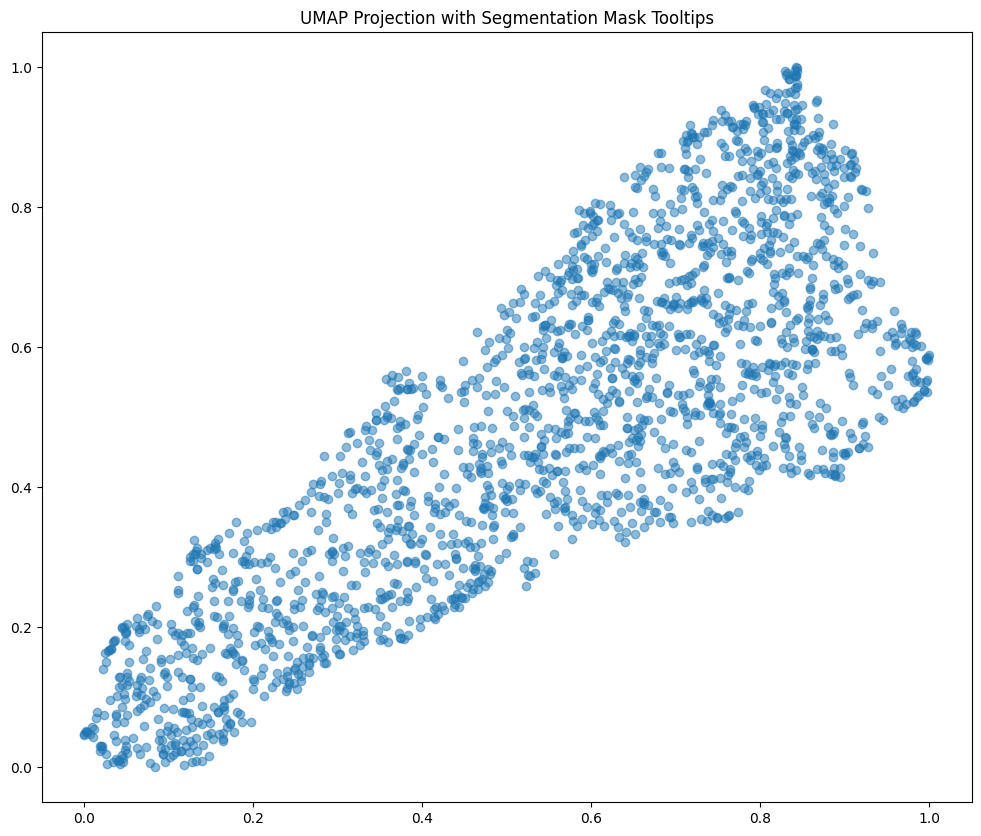

In [35]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.preprocessing import MinMaxScaler

# Use widget backend for interactive plots
%matplotlib inline

def create_umap_with_mask_hover(embeddings, binary_masks, n_samples=None, random_state=42):
    """
    Jupyter-optimized UMAP visualization with binary mask hover.
    
    Parameters:
    - embeddings: (N, embed_dim) array
    - binary_masks: (N, 224, 224) binary masks
    - n_samples: number of samples to display
    - random_state: random seed
    """
    # Sample if requested
    if n_samples is not None and n_samples < len(embeddings):
        rng = np.random.RandomState(random_state)
        indices = rng.choice(len(embeddings), n_samples, replace=False)
        embeddings = embeddings[indices]
        binary_masks = binary_masks[indices]
    
    # UMAP reduction
    reducer = umap.UMAP(random_state=random_state)
    umap_embeddings = reducer.fit_transform(embeddings)
    
    # Normalize coordinates
    scaler = MinMaxScaler()
    coords = scaler.fit_transform(umap_embeddings)
    
    # Create figure with specific DPI
    fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
    scatter = ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5)
    plt.title("UMAP with Binary Mask Hover")
    
    # Prepare image boxes
    image_boxes = []
    for mask in binary_masks:
        mask = (mask > 0).astype(float)  # Ensure binary
        img_box = OffsetImage(mask, cmap='gray', zoom=0.3)
        image_boxes.append(img_box)
    
    # Create annotation initially hidden
    annot = AnnotationBbox(image_boxes[0], (0,0), 
                          xybox=(50,50),
                          xycoords='data',
                          boxcoords="offset points",
                          pad=0.5,
                          arrowprops=dict(arrowstyle="->"))
    annot.set_visible(False)
    ax.add_artist(annot)
    
    # Hover function
    def update_annot(ind):
        pos = scatter.get_offsets()[ind]
        annot.xy = pos
        annot.set_visible(True)
        annot.offsetbox = image_boxes[ind]
        fig.canvas.draw_idle()
    
    # Motion notify event
    def hover(event):
        vis = annot.get_visible()
        if event.inaxes == ax:
            cont, ind = scatter.contains(event)
            if cont:
                update_annot(ind["ind"][0])
            else:
                if vis:
                    annot.set_visible(False)
                    fig.canvas.draw_idle()
    
    fig.canvas.mpl_connect("motion_notify_event", hover)
    plt.show()

embedding_matrix = embed
masks = dataset[:][0]
create_umap_with_mask_tooltips(embedding_matrix, masks)

/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


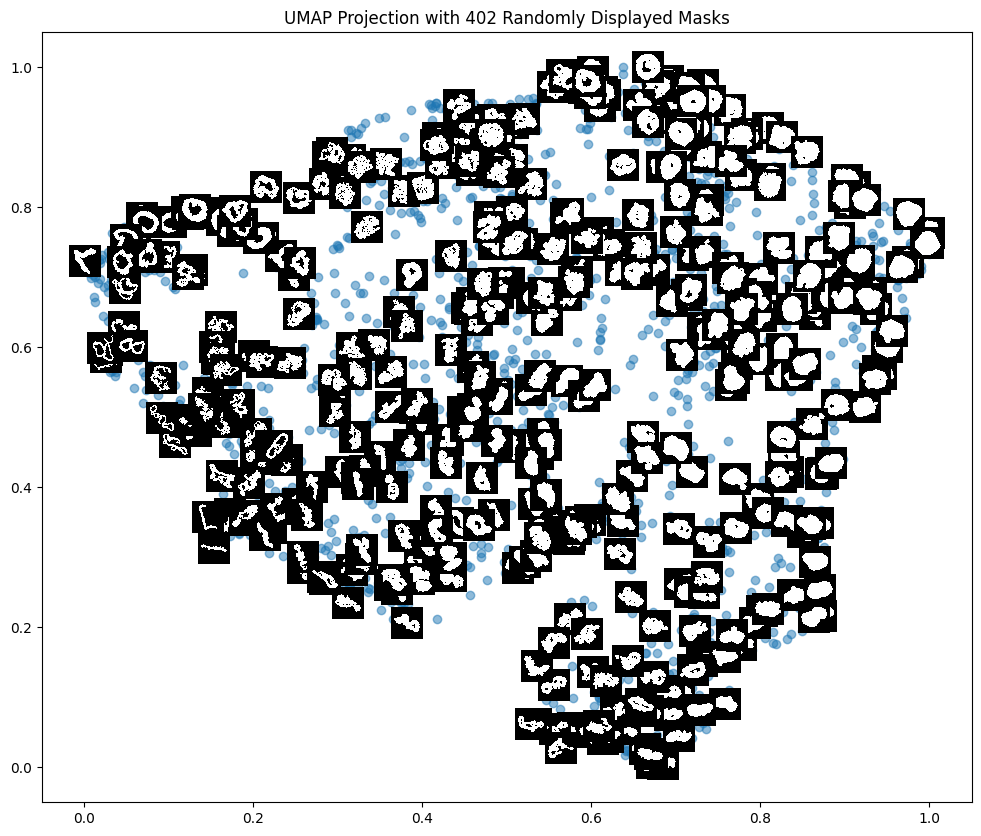

In [59]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.preprocessing import MinMaxScaler

# Use inline backend
%matplotlib inline

def create_umap_with_displayed_masks(embeddings, binary_masks, patient_ids, display_ratio=0.1, random_state=42):
    """
    UMAP visualization with randomly sampled masks displayed directly on plot.
    
    Parameters:
    - embeddings: (N, embed_dim) array
    - binary_masks: (N, 224, 224) binary masks
    - display_ratio: fraction of images to display (0 to 1)
    - random_state: random seed
    """
    # Calculate number of images to display
    n_display = max(1, int(len(embeddings) * display_ratio))
    
    # Randomly select indices for display
    rng = np.random.RandomState(random_state)
    display_indices = rng.choice(len(embeddings), n_display, replace=False)
    
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(random_state=random_state)
    umap_embeddings = reducer.fit_transform(embeddings)
    
    # Normalize coordinates to [0,1] for better plotting
    scaler = MinMaxScaler()
    coords = scaler.fit_transform(umap_embeddings)
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
    
    # Plot all points
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5)
    plt.title(f"UMAP Projection with {n_display} Randomly Displayed Masks")
    
    # Display selected masks
    for idx in display_indices:
        # Get binary mask and normalize to [0,1]
        mask = binary_masks[idx].numpy()
        
        # Create image box
        img_box = OffsetImage(mask, cmap='gray', zoom=0.1)  # Smaller zoom for better visibility
        
        # Create annotation at UMAP coordinates
        ab = AnnotationBbox(img_box, 
                          (coords[idx, 0], coords[idx, 1]),
                          frameon=False,
                          pad=0.1)
        ax.add_artist(ab)
    
    plt.show()

# Example usage:
embed = pickle.load(open("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/code/embeddings_resnet152.pkl", "rb"))
embedding_matrix = embed
masks = dataset[:][0]
create_umap_with_displayed_masks(embedding_matrix, masks, dataset.organoid_patient_ids, display_ratio=0.2)

/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_2732418/3074170059.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv', num_patients)


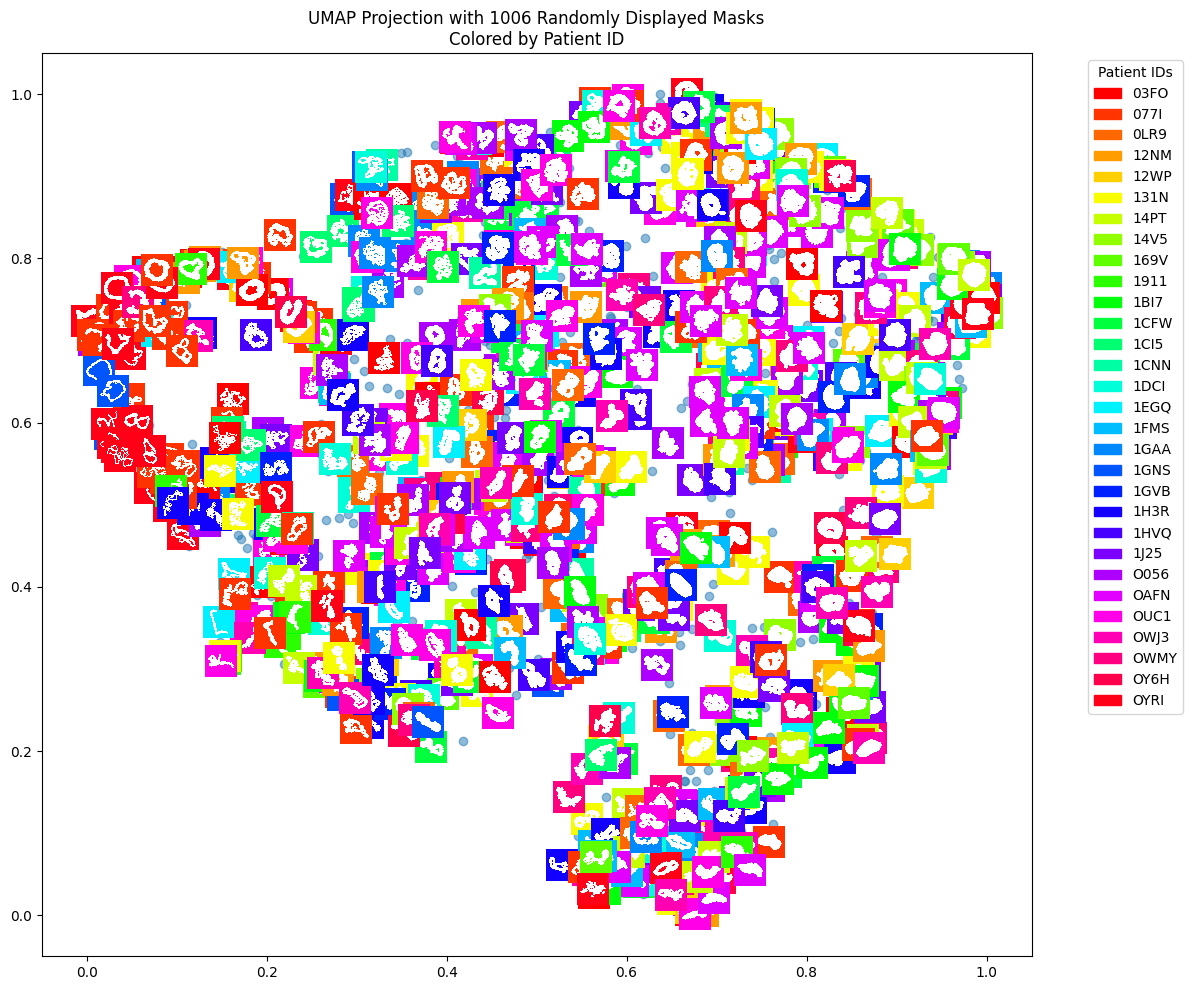

In [66]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.preprocessing import MinMaxScaler
import matplotlib.patches as mpatches

def create_umap_with_displayed_masks(embeddings, binary_masks, patient_ids, display_ratio=0.1, random_state=42):
    """
    UMAP visualization with randomly sampled masks displayed directly on plot.
    Each displayed mask has a background color based on patient ID.
    
    Parameters:
    - embeddings: (N, embed_dim) array
    - binary_masks: (N, 224, 224) binary masks
    - patient_ids: list of patient IDs (strings) corresponding to each mask
    - display_ratio: fraction of images to display (0 to 1)
    - random_state: random seed
    """
    # Calculate number of images to display
    n_display = max(1, int(len(embeddings) * display_ratio))
    
    # Randomly select indices for display
    rng = np.random.RandomState(random_state)
    display_indices = rng.choice(len(embeddings), n_display, replace=False)
    
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(random_state=random_state)
    umap_embeddings = reducer.fit_transform(embeddings)
    
    # Normalize coordinates to [0,1] for better plotting
    scaler = MinMaxScaler()
    coords = scaler.fit_transform(umap_embeddings)
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
    
    # Plot all points
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5)
    plt.title(f"UMAP Projection with {n_display} Randomly Displayed Masks\nColored by Patient ID")
    
    # Create color mapping for patient IDs
    unique_patients = np.unique(patient_ids)
    num_patients = len(unique_patients)
    
    # Create a colormap with enough distinct colors
    cmap = plt.cm.get_cmap('hsv', num_patients)
    patient_to_color = {patient: cmap(i) for i, patient in enumerate(unique_patients)}
    
    # Display selected masks with patient-colored background
    for idx in display_indices:
        # Get binary mask
        mask = binary_masks[idx].numpy()
        
        # Create a colored background (RGBA array)
        bg_color = patient_to_color[patient_ids[idx]]
        bg_array = np.zeros((*mask.shape, 4))  # Create RGBA array
        bg_array[..., :3] = bg_color[:3]  # Set RGB
        bg_array[..., 3] = 1  # Set alpha (transparency)
        
        # Combine mask with background
        display_img = np.where(mask[..., None] > 0, 
                             np.array([1, 1, 1, 1]),  # White for mask
                             bg_array)  # Colored background
        
        # Create image box
        img_box = OffsetImage(display_img, zoom=0.1)
        
        # Create annotation at UMAP coordinates
        ab = AnnotationBbox(img_box, 
                          (coords[idx, 0], coords[idx, 1]),
                          frameon=False,
                          pad=0.1)
        ax.add_artist(ab)
    
    # Create legend
    legend_patches = [mpatches.Patch(color=patient_to_color[pid], label=pid) 
                     for pid in unique_patients]
    ax.legend(handles=legend_patches, 
              title='Patient IDs',
              bbox_to_anchor=(1.05, 1), 
              loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Example usage:
embed = pickle.load(open("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/code/embeddings_resnet152.pkl", "rb"))
embedding_matrix = embed
masks = dataset[:][0]
create_umap_with_displayed_masks(embedding_matrix, masks, dataset.organoid_patient_ids, display_ratio=0.5)

(27256, 25665)


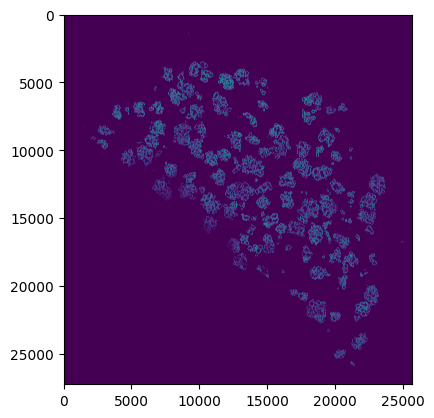

In [66]:
im = tifffile.imread("/work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/raw/CRC_PDO/hImmune_v1_dapi/0LR9/output-XETG00059__0003881__0RL9_not_OZ84__20250505__170804/aux_outputs/per_cycle_channel_images/cycle_01_blu.tiff")
im = tifffile.imread("/work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/raw/CRC_PDO/hImmune_v1_dapi/0LR9/output-XETG00059__0003881__0RL9_not_OZ84__20250505__170804/morphology_focus/morphology_focus_0000.ome.tif")
print(im.shape)
plt.imshow(im)

In [67]:
im = tifffile.imread("/work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/raw/CRC_PDO/hImmune_v1_dapi/0LR9/output-XETG00059__0003881__0RL9_not_OZ84__20250505__170804/morphology.ome.tif")
print(im.shape)
plt.imshow(im)

(13, 27256, 25665)


: 

: 